#**Anscombes Quartet**


First we have to mount our google drive so we can access the excel file with our data

#**Importing libraries**



In [145]:
#Lets import our libraries like we did before
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import math
import json

# for easier to read
def p(obj: dict[any, any]):
    print(json.dumps(obj, indent=4))

SETS = {
    'x1': 'y1',
    'x2': 'y2',
    'x3': 'y3',
    'x4': 'y4'
}

#**Importing our data**




We can use the ***!ls*** command to see what folders are in our current directory and use it to write our path to the Anscombes Quartet data set.

Spaces in your directory path can cause issues so be careful!

In [146]:
!ls

AnscombesQuartet.ipynb           IntrotoPlotting.ipynb
AnscombesQuartet_Extension.ipynb Maths for Computer Science.ipynb
Extension


Now we want to import our data as a pandas data frame and print the data so we can have a look at it.

In [188]:
AQ = pd.read_excel('../Data/AnscombesQuartet.xlsx')
print(AQ)
#Here i have set the name of the data frame to AQ- its best to have short names that are still easily identified
#You will have to alter the path above to locate and import the data set depending on where you have saved it on your drive.


# print(AQ.mean(axis=0))

(x1_mean, x2_mean, x3_mean, x4_mean) = [AQ.mean(axis=0)[i] for i in range(8)][0:4]
# print(f"Mean values for x:\n{(x1_mean, x2_mean, x3_mean, x4_mean)}")

print(x1_mean, x2_mean, x3_mean, x4_mean)
# print("=" * 30)

    x1  x2  x3  x4     y1    y2     y3     y4
0   10  10  10   8   8.04  9.14   7.46   6.58
1    8   8   8   8   6.95  8.14   6.77   5.76
2   13  13  13   8   7.58  8.74  12.74   7.71
3    9   9   9   8   8.81  8.77   7.11   8.84
4   11  11  11   8   8.33  9.26   7.81   8.47
5   14  14  14   8   9.96  8.10   8.84   7.04
6    6   6   6   8   7.24  6.13   6.08   5.25
7    4   4   4  19   4.26  3.10   5.39  12.50
8   12  12  12   8  10.84  9.13   8.15   5.56
9    7   7   7   8   4.82  7.26   6.42   7.91
10   5   5   5   8   5.68  4.74   5.73   6.89
9.0 9.0 9.0 9.0


/var/folders/zb/db7fspw16sz604cw1ls073cm0000gn/T/ipykernel_34149/238871362.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (x1_mean, x2_mean, x3_mean, x4_mean) = [AQ.mean(axis=0)[i] for i in range(8)][0:4]


We should be able to see we have four data sets denoted by their number: 1, 2, 3 and 4.

#**Summary statistics for each data set**

First we want to calculate the mean x and y for all four of our data sets.
You are free to choose how you approach this. You can take a manual approach or research the pandas documentation online to look for a quicker way.

In [190]:
#Mean y values
(y1_mean, y2_mean, y3_mean, y4_mean) = (AQ.mean(axis=0)[i] for i in range(4, 8))

print([x1_mean, x2_mean, x3_mean, x4_mean, y1_mean, y2_mean, y3_mean, y4_mean])


[9.0, 9.0, 9.0, 9.0, 7.500909090909093, 7.50090909090909, 7.5, 7.500909090909091]


/var/folders/zb/db7fspw16sz604cw1ls073cm0000gn/T/ipykernel_34149/2122778434.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (y1_mean, y2_mean, y3_mean, y4_mean) = (AQ.mean(axis=0)[i] for i in range(4, 8))


In [191]:
medians = [AQ.median(axis = 0)[i] for i in range(8)]
medians

/var/folders/zb/db7fspw16sz604cw1ls073cm0000gn/T/ipykernel_34149/2764489976.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  medians = [AQ.median(axis = 0)[i] for i in range(8)]


[9.0, 9.0, 9.0, 8.0, 7.58, 8.14, 7.11, 7.04]

Next we are going to calculate the standard deviation of our data sets.
Again you can do this manually or use the pandas functions.

In [149]:
# Standard deviation values x and y

means = [x1_mean, x2_mean, x3_mean, x4_mean, y1_mean, y2_mean, y3_mean, y4_mean]
stdValues = {}

for col in range(8):
    # Get the mean of the column using the previous calculated values
    mean = means[col]
    # print(f"Mean: {mean}")
    s: float = 0

    # SD = √(((value - mean)^2) / N)
    column = AQ[AQ.columns[col]]
    for val in column:
        s += ((val - mean) ** 2)
    sd = math.sqrt(s / len(column))


    # Add this value to a dictionary of all SD values.
    stdValues[AQ.columns[col]] = sd

    pass

p(stdValues)


{
    "x1": 3.1622776601683795,
    "x2": 3.1622776601683795,
    "x3": 3.1622776601683795,
    "x4": 3.1622776601683795,
    "y1": 1.937024215108669,
    "y2": 1.9371086914896203,
    "y3": 1.9359329439927313,
    "y4": 1.9360806451340837
}


In [150]:
# Standard deviation values y

columns = ['y1', 'y2', 'y3', 'y4']

_stdValues = {}

for column in columns:
    x = list(AQ[column])
    mean = np.mean(x)

    print(f"Mean: {mean}")

    s: float = 0
    for i in x:
        s += ((i - mean) ** 2)
    standardDeviation = math.sqrt(s / len(x))

    _stdValues[column] = standardDeviation


p(_stdValues)

Mean: 7.500909090909093
Mean: 7.50090909090909
Mean: 7.5
Mean: 7.500909090909091
{
    "y1": 1.937024215108669,
    "y2": 1.9371086914896203,
    "y3": 1.9359329439927313,
    "y4": 1.9360806451340837
}


Now we are going to investigate the **correlation** of our x and y values in each data set.

We are going to use the numpy corrcoef command, research the literature to figure out how to use this.

In [151]:
# Correlation


correlations: list[float] = []

for xn, yn in SETS.items():
    # Iterate through each pair of x's and y's
    x, y = np.array(AQ[xn]), np.array(AQ[yn])

    corrcoef = np.corrcoef(x, y)[0][1]
    print(f"Correlation between {xn} & {yn} is {corrcoef}")
    correlations.append(corrcoef)

[corrcoef_x1y1, corrcoef_x2y2, corrcoef_x3y3, corrcoef_x4y4] = correlations

# print([corrcoef_x1y1, corrcoef_x2y2, corrcoef_x3y3, corrcoef_x4y4])

# correlation_x1y1 = 
# correlation_x2y2 =
# correlation_x3y3 =
# correlation_x4y4 =

Correlation between x1 & y1 is 0.81642051634484
Correlation between x2 & y2 is 0.8162365060002428
Correlation between x3 & y3 is 0.8162867394895984
Correlation between x4 & y4 is 0.8165214368885028


Next we want to calculate Linear regression slope and the intercepts for the data sets.

We are going to use the numpy polyfit command to fit our data sets, research the literature to figure out how to use this.

polyfit will return two variable- our gradient (m) and the intercept (c).

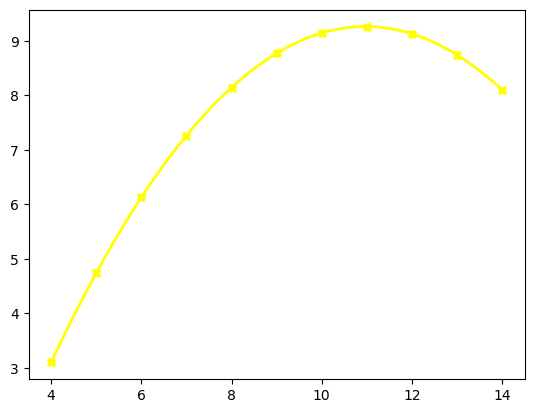

In [152]:
# Linear Regression slope and intercept

colors = ["red", "yellow", "green", "blue"]

filters = input("Enter indexes: ") # choose which ones to plot

for i, (xn, yn) in enumerate(SETS.items()):

    if not str(i) in filters:
        continue

    x, y = np.array(AQ[xn]), np.array(AQ[yn])
    [a, m, c] = np.polyfit(x, y, 2)
    
    plt.plot(x, y, color=colors[i], linestyle='', marker='X')

    px = np.linspace(min(x), max(x), 1000)
    fPy = lambda px: a * px ** 2 + px * m + c

    py = [fPy(k) for k in px]
    plt.plot(px, py, color=colors[i], linewidth=2)


    pass

# m1,c1 =
# m2,c2 =
# m3,c3 =
# m4,c4 =

Now we want to evaluate how well our data sets match the regression lines we have found.

We are going to use Residual sum of squares error method.

**Residuals**

In [153]:
# (actual - predicted)^2

# Residual Sum of Squares
r_squared_values: list[float] = []
sst_values: list[float] = []
ssr_values: list[float] = []
best_fit_m: list[float] = []
best_fit_c: list[float] = []

for i, (xn, yn) in enumerate(SETS.items()):
    x, y = np.array(AQ[xn]), np.array(AQ[yn])
    [m, c] = np.polyfit(x, y, 1)
    best_fit_m.append(m)
    best_fit_c.append(c)

    predicted_y = m * x + c
    residuals = y - predicted_y

    ss_total = np.sum(np.square(y - means[i + 4]))
    sst_values.append(ss_total)

    ss_residual = np.sum(np.square(residuals))
    ssr_values.append(ss_residual)
    
    r_squared = 1 - (ss_residual / ss_total)
    r_squared_values.append(r_squared)

print(f"{r_squared_values = }")


r_squared_values = [0.6665424595087749, 0.6662420337274844, 0.6663240410665592, 0.6667072568984653]


Summation of the squares

In [154]:


# (actual - predicted)^2

# Residual Sum of Squares

_residuals = []


for i, (xn, yn) in enumerate(SETS.items()):
    x, y = np.array(AQ[xn]), np.array(AQ[yn])

    sum: float = 0

    for actualY in y:
        meanY = means[i + 4]

        sum += (actualY - meanY) ** 2

        # print(f"{(actualY - predictedY) ** 2 = }")

    _residuals.append(round(sum, 5))
    
    pass

print(f"{_residuals = }")

_residuals = [41.27269, 41.27629, 41.2262, 41.23249]


Determining R squared coefficient

In [155]:
R2_1  = 1 - (RSSY_1 / TSS_1)
R2_2  = 1 - (RSSY_2 / TSS_2)
R2_3  = 1 - (RSSY_3 / TSS_3)
R2_4  = 1 - (RSSY_4 / TSS_4)

NameError: name 'RSSY_1' is not defined

Lastly we want to display all of our data so we can compare the values across the data sets.

We can do this by creating a new data frame with our summary statistics.



,y1,y2,y3,y4
count,11.0,11.0,11.0,11.0
mean,7.500909,7.500909,7.5,7.500909
std,2.031568,2.031657,2.030424,2.030579
min,4.26,3.1,5.39,5.25
25%,6.315,6.695,6.25,6.17
50%,7.58,8.14,7.11,7.04
75%,8.57,8.95,7.98,8.19
max,10.84,9.26,12.74,12.5
cor,0.816421,0.816237,0.816287,0.816521
SSR,13.76269,13.776291,13.756192,13.74249


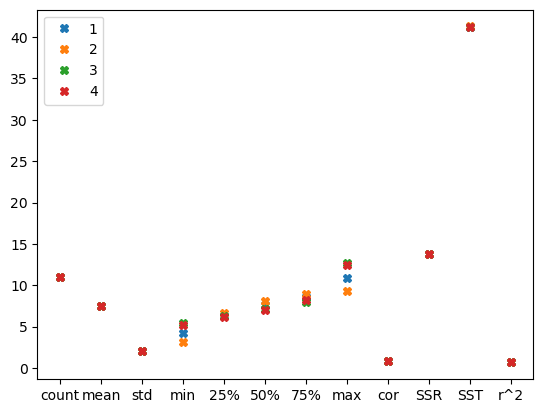

In [181]:


data = pd.DataFrame({
    'y1': AQ['y1'],
    'y2': AQ['y2'],
    'y3': AQ['y3'],
    'y4': AQ['y4']
})

summary_stats = pd.DataFrame(data.describe(include='all'))

summary_stats.loc["cor"] = correlations
summary_stats.loc["SSR"] = ssr_values
summary_stats.loc["SST"] = sst_values

summary_stats.loc["r^2"] = r_squared_values


# summary_stats.loc["r^2"] = [1,1,1,1,1,1,1,1]

# your code goes here

plt.plot(summary_stats, marker='X', linestyle='')
plt.legend("1234")

summary_stats.loc["linear_regression"] = [f"y = {best_fit_m[i]:.2f}x + {best_fit_c[i]:.2f}" for i in range(4)]
summary_stats

Now we can compare our statistics- how do they look? What do you notice?

#**Data Visualisation**
From the statistics we might thing our data is very similar- lets plot the data sets so we can see how they look visually.

You can plot each data set seperately or using subplots- its upto you!

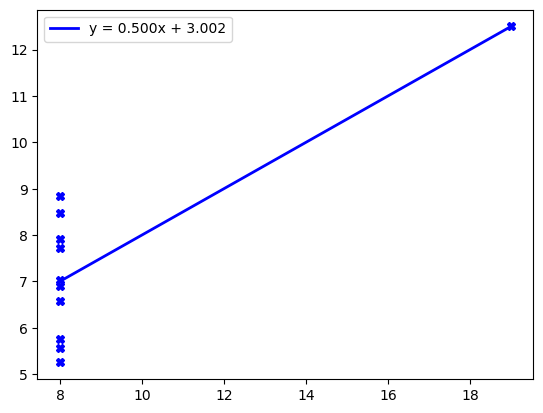

In [187]:

# plot all four plots



colors = ["red", "orange", "green", "blue"]

filters = input("Enter options: ")

if not filters: filters = "0123"

shouldPolyfit = '-p' in filters
shouldUseQuadratic = '-q' in filters and shouldPolyfit


for i, (xn, yn) in enumerate(SETS.items()):

    if not str(i) in filters:
        continue
    
    x, y = np.array(AQ[xn]), np.array(AQ[yn])

    if shouldPolyfit:
        px = np.linspace(min(x), max(x), 1000)
        match shouldUseQuadratic:
            case True:
                [a, m, c] = np.polyfit(x, y, 2)
            

                
                fPy = lambda px: a * px ** 2 + px * m + c
                py = [fPy(k) for k in px]
                
                plt.plot(px, py, color=colors[i], linewidth=2, label=f"y = {a:.3f}x^2 + {m:.3f}x + {c:.3f}")
                
            case False:
                [m, c] = np.polyfit(x, y, 1)
                fPy = lambda px: px * m + c
                py = [fPy(k) for k in px]
                
                plt.plot(px, py, color=colors[i], linewidth=2, label=f"y = {m:.3f}x + {c:.3f}")



    plt.plot(x, y, color=colors[i], linestyle='', marker='X')


plt.legend()